In [242]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Question 1

In [243]:
def intensity_transform(im, breakpoints):
    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    c = np.array(breakpoints)
    t1 = np.linspace(c[0,1],c[1,1], c[1,0]-c[0,0]+1).astype('uint8')
    t2 = np.linspace(c[1,1]+1,c[2,1], 1)
    t3 = np.linspace(c[2,1]+1,c[3,1], c[3,0]-c[2,0]-1).astype('uint8')
    t4 = np.linspace(c[4,1],c[3,1]+1, 1)
    t5 = np.linspace(c[4,1]+1,c[5,1], c[5,0]-c[4,0]-1).astype('uint8')
    print(len(t1),len(t2),len(t3),len(t4),len(t5))
    transform = np.concatenate((t1, t2,t3,t4), axis=0).astype('uint8')
    transform = np.concatenate((transform, t5), axis=0).astype('uint8')
    print(len(transform))
    image_transformed = cv.LUT(img, transform)
    fig, ax = plt.subplots(1,2, figsize = (5,6))
    ax[0].plot(transform)
    ax[0].set_xlabel(r'Input Intensity')
    ax[0].set_ylabel('Output Intensity')
    ax[0].set_xlim(0,255)
    ax[0].set_ylim(0,255)
    ax[0].set_aspect('equal') 
    ax[0].grid()
    ax[1].imshow(image_transformed, cmap='gray', vmin=0, vmax=255)
    ax[1].set_title('Intensity Transformed Image')
    ax[1].axis('off')
    plt.show()

51 1 99 1 104
256


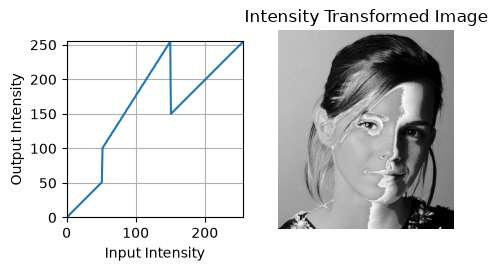

In [244]:
im = "emma.jpg"
breakpoints = [(0,0),(50,50),(50,100),(150,255),(150,150),(255,255)]
intensity_transform(im,breakpoints)

Question 2

GRAY

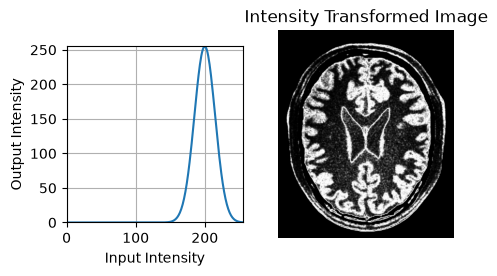

In [245]:
img = cv.imread("brain.png", cv.IMREAD_GRAYSCALE)
mu = 200
sigma = 15
x = np.linspace (0 , 255 , 256)
t = 255 * np.exp ( -(( x - mu ) **2) / (2 * sigma **2) )
t = np.clip (t , 0 , 255)
g = t[img]
fig, ax = plt.subplots(1,2, figsize = (5,6))
ax[0].plot(t)
ax[0].set_xlabel(r'Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].set_aspect('equal') 
ax[0].grid()
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Intensity Transformed Image')
ax[1].axis('off')
plt.show()

WHITE

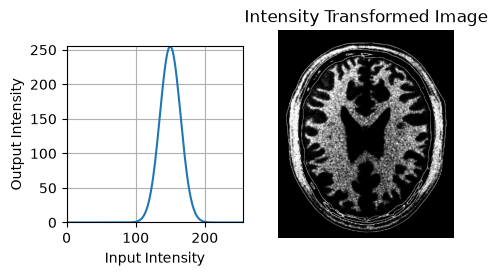

In [246]:
img = cv.imread("brain.png", cv.IMREAD_GRAYSCALE)
mu = 150
sigma = 15
x = np.linspace (0 , 255 , 256)
t = 255 * np.exp ( -(( x - mu ) **2) / (2 * sigma **2) )
t = np.clip (t , 0 , 255)
g = t[img]
fig, ax = plt.subplots(1,2, figsize = (5,6))
ax[0].plot(t)
ax[0].set_xlabel(r'Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].set_aspect('equal') 
ax[0].grid()
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Intensity Transformed Image')
ax[1].axis('off')
plt.show()

Question 3

In [247]:
im = cv.imread("gamma.png")
im_original = cv.cvtColor(im, cv.COLOR_BGR2RGB) 
im_test = cv.cvtColor(im, cv.COLOR_BGR2LAB)
assert im is not None

In [248]:
L,a,b = cv.split(im_test)
gamma = 0.75
t = np.array([(i/255.0)**(gamma)*255 for i in np.arange(0, 256)]).astype('uint8')
L_mod = cv.LUT(L, t)
im_merged = cv.merge([L_mod,a,b])
im_mod = cv.cvtColor(im_merged, cv.COLOR_LAB2RGB)

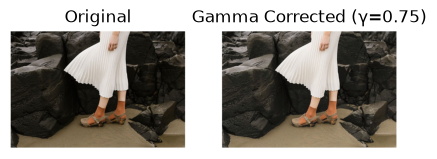

In [249]:
fig, axs = plt.subplots(1, 2, figsize=(5, 6))
axs[0].imshow(im_original)
axs[0].set_title('Original')
axs[0].axis('off')  
axs[1].imshow(im_mod)
axs[1].set_title(f'Gamma Corrected (γ={gamma})')
axs[1].axis('off')
plt.show()

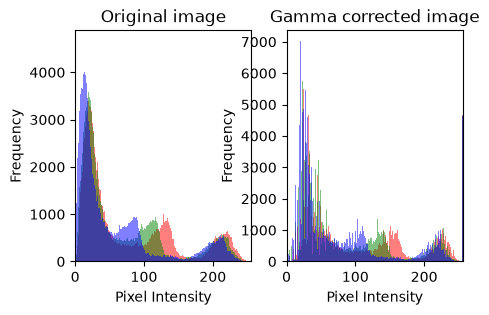

In [250]:
colors = ('r', 'g', 'b')
plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1)
for i in range(3):
    plt.hist(im_original[:, :, i].ravel(), bins=256, range=(0, 256), color=colors[i], alpha=0.5)
plt.title('Original image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.subplot(1, 2, 2)
for i in range(3):
    plt.hist(im_mod[:, :, i].ravel(), bins=256, range=(0, 256), color=colors[i], alpha=0.5)
plt.title('Gamma corrected image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

Question 4

In [251]:
im = cv.imread('spiderman.png')
assert im is not None
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
H, S, V = cv.split(im_hsv)

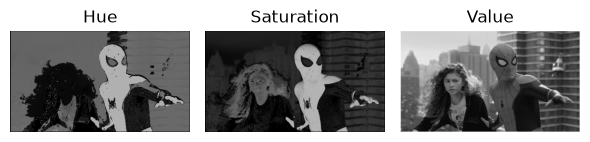

In [252]:
fig, ax = plt.subplots(1, 3, figsize=(6, 4))
ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue')
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation')
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value')
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

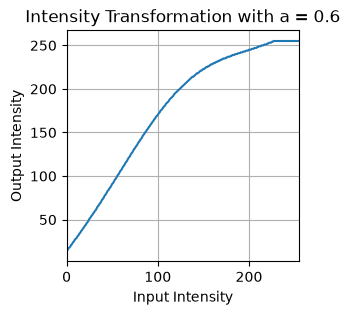

In [253]:
a = 0.6
sigma = 70.0 
x = np.arange(0, 256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype('uint8')
plt.figure(figsize=(3, 3))
plt.plot(x, f)
plt.title('Intensity Transformation with a = 0.6')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid()
plt.xlim([0, 255])
plt.xlim([0, 255])
plt.show()

In [254]:
S_mod = cv.LUT(S, f)
im_merged = cv.merge([H, S_mod, V])
im_modified = cv.cvtColor(im_merged, cv.COLOR_HSV2RGB)

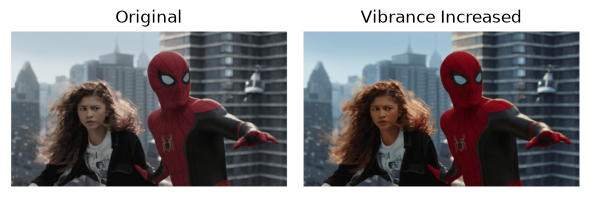

In [255]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(im_rgb)
ax[0].set_title('Original')
ax[1].imshow(im_modified)
ax[1].set_title('Vibrance Increased')
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

Question 5

(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

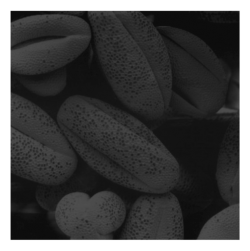

In [256]:
im = cv.imread("rocks.png", cv.IMREAD_GRAYSCALE)
fig,ax = plt.subplots(figsize=(3,3))
ax.imshow(im, cmap='gray', vmin=0, vmax=255)
ax.axis("off")

In [257]:
L = 256
M,N = im.shape
hist = cv.calcHist([im],[0], None, [L],[0,L])
hist_sum = hist.cumsum()
t = np.array([(L-1)/(M*N)*hist_sum[k] for k in range(256)]).astype("uint8")
im_eq = t[im]

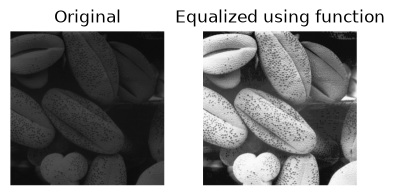

In [258]:
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(im_eq, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized using function')
ax[1].axis("off")

# Show the plot
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

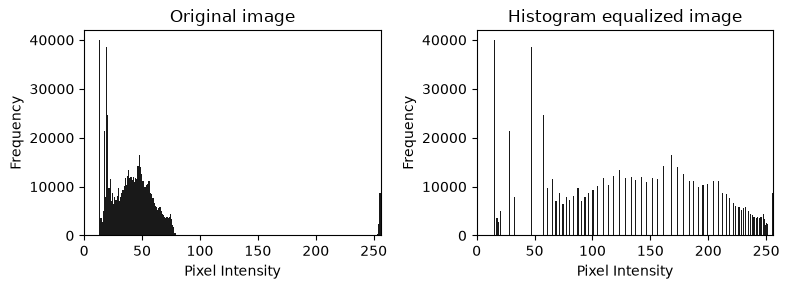

In [259]:
hist1 = cv.calcHist([im], [0], None, [256], [0, 256])
hist2 = cv.calcHist([im_eq], [0], None, [256], [0, 256])
plt.figure(figsize=(10, 5))
im_flat = im.flatten()
im_eq_flat = im_eq.flatten()
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.hist(im_flat, bins=256, range=(0, 256), color='black', alpha=0.9)
plt.title('Original image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.subplot(1, 2, 2)
plt.hist(im_eq_flat, bins=256, range=(0, 256), color='black', alpha=0.9)
plt.title('Histogram equalized image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.tight_layout()
plt.show()

Question 6

In [260]:
q6 = cv.imread('jennifer.png')
assert im is not None
q6_hsv = cv.cvtColor(q6, cv.COLOR_BGR2HSV)
q6_rgb = cv.cvtColor(q6, cv.COLOR_BGR2RGB)
H, S, V = cv.split(q6_hsv)

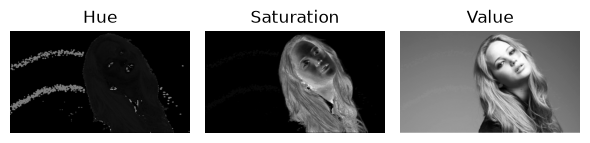

In [261]:
fig, ax = plt.subplots(1, 3, figsize=(6, 4))
ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue')
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation')
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value')
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

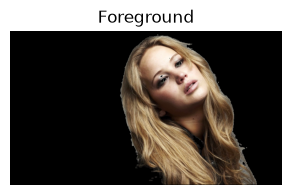

In [262]:
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)
foreground = cv.bitwise_and(q6, q6, mask=mask)
plt.figure(figsize=(5, 2))
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Foreground')
plt.axis('off')
plt.show()

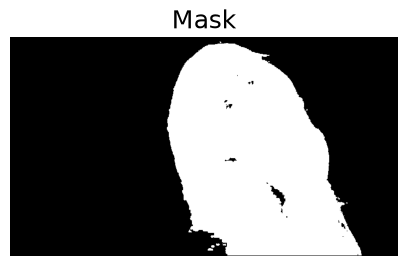

In [263]:
plt.figure(figsize=(5, 4))
plt.imshow(mask, cmap='gray')
plt.title('Mask', fontsize=18)
plt.axis('off')
plt.show()

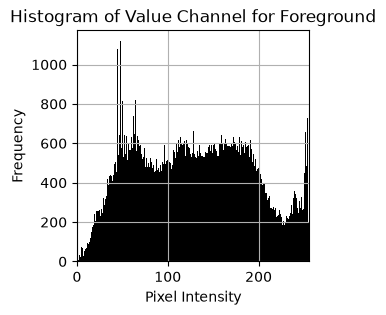

In [264]:
foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
H_fg, S_fg, V_fg = cv.split(foreground_hsv)
hist = cv.calcHist([V_fg], [0], mask, [256], [0, 256])
x_positions = np.arange(len(hist))
plt.figure(figsize = (3,3))
plt.bar(x_positions, hist.flatten(), color='black', width=1)
plt.title('Histogram of Value Channel for Foreground')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

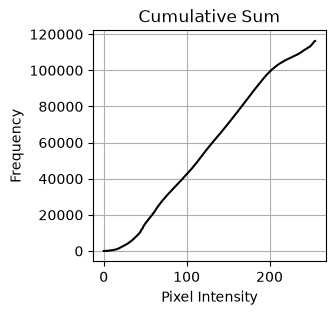

In [265]:
cdf = hist.cumsum()
plt.figure(figsize=(3,3))
plt.plot(cdf, color='black')
plt.title('Cumulative Sum')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [266]:
pixels = cdf[-1]
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")
V_eq = t[V_fg]
hist = cv.calcHist([V_eq], [0], mask, [256], [0, 256])
merged = cv.merge([H_fg, S_fg, V_eq])
foreground_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)

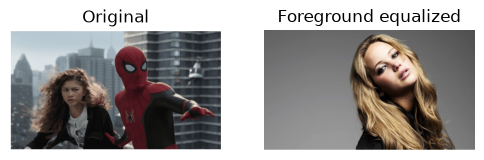

In [267]:
background = cv.bitwise_and(q6, q6, mask=cv.bitwise_not(mask))
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), foreground_modified)
fig, axs = plt.subplots(1, 2, figsize=(6, 4))
axs[0].imshow(im_rgb)
axs[0].set_title('Original')
axs[0].axis('off') 
axs[1].imshow(result)
axs[1].set_title('Foreground equalized')
axs[1].axis('off')
plt.show()

Question 7

In [268]:
q7 = cv.imread('einstein.png', cv.IMREAD_GRAYSCALE)
assert q7 is not None

In [269]:
sobel_x = np.array([[1, 0, -1], 
                    [2, 0, -2], 
                    [1, 0, -1]])
sobel_y = np.array([[1, 2, 1], 
                    [0, 0, 0], 
                    [-1, -2, -1]])
print("Sobel X filter:")
print(sobel_x)
print("\nSobel Y filter:")
print(sobel_y)

Sobel X filter:
[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]

Sobel Y filter:
[[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


In [270]:
sobel_x_filtered = cv.filter2D(q7, cv.CV_64F, sobel_x)
sobel_y_filtered = cv.filter2D(q7, cv.CV_64F, sobel_y)

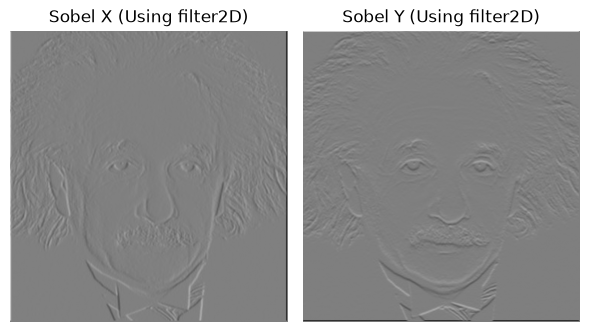

In [271]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(sobel_x_filtered, cmap='gray')
ax[0].set_title('Sobel X (Using filter2D)')
ax[0].axis("off")
ax[1].imshow(sobel_y_filtered, cmap='gray')
ax[1].set_title('Sobel Y (Using filter2D)')
ax[1].axis("off")
plt.tight_layout()
plt.show()

In [272]:
def apply_filter(image, filter):
    [rows, columns] = np.shape(image) # Get rows and columns of the image
    filtered_image = np.zeros(shape=(rows, columns)) # Create empty image
    
    for i in range(rows - 2):
        for j in range(columns - 2): # Process 2D convolution
            value = np.sum(np.multiply(filter, image[i:i + 3, j:j + 3])) 
            filtered_image[i + 1, j + 1] = value
    
    return filtered_image


In [273]:
# Apply the Sobel filter in the X direction
sobel_x_filtered = apply_filter(einstein, sobel_x)

# Apply the Sobel filter in the Y direction
sobel_y_filtered = apply_filter(einstein, sobel_y)

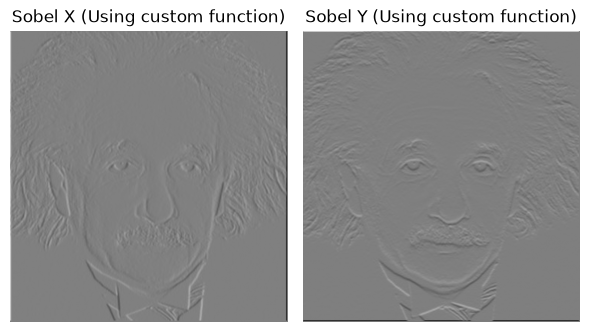

In [274]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(sobel_x_filtered, cmap='gray')
ax[0].set_title('Sobel X (Using custom function)')
ax[0].axis("off")
ax[1].imshow(sobel_y_filtered, cmap='gray')
ax[1].set_title('Sobel Y (Using custom function)')
ax[1].axis("off")
plt.tight_layout()
plt.show()

In [275]:
# Sobel x filter seperated
sobel_x_vertical = np.array([[1], [2], [1]])
sobel_x_horizontal = np.array([[1, 0, -1]])

# Sobel y filter seperated
sobel_y_vertical = np.array([[1], [0], [-1]])
sobel_y_horizontal = np.array([[1, 2, 1]])

# Apply the vertical and horizontal filters consecutively
x_mid = cv.filter2D(einstein, cv.CV_64F, sobel_x_horizontal)
x_filtered_image = cv.filter2D(x_mid, cv.CV_64F, sobel_x_vertical)

y_mid = cv.filter2D(einstein, cv.CV_64F, sobel_y_vertical)
y_filtered_image = cv.filter2D(y_mid, cv.CV_64F, sobel_y_horizontal)

print(sobel_x_vertical @ sobel_x_horizontal)
print(sobel_y_vertical @ sobel_y_horizontal)

[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
[[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


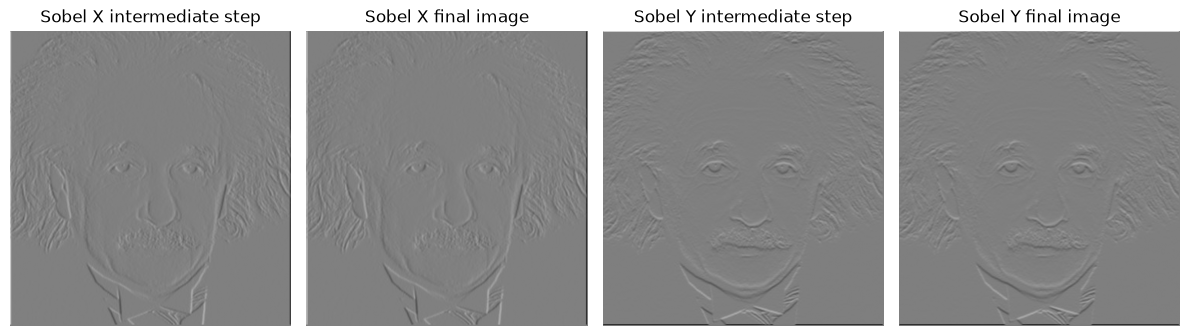

In [276]:
fig, ax = plt.subplots(1, 4, figsize=(12, 8))
ax[0].imshow(x_mid, cmap='gray')
ax[0].set_title('Sobel X intermediate step')
ax[0].axis("off")
ax[1].imshow(x_filtered_image, cmap='gray')
ax[1].set_title('Sobel X final image')
ax[1].axis("off")
ax[2].imshow(y_mid, cmap='gray')
ax[2].set_title('Sobel Y intermediate step')
ax[2].axis("off")
ax[3].imshow(y_filtered_image, cmap='gray')
ax[3].set_title('Sobel Y final image')
ax[3].axis("off")
plt.tight_layout()
plt.show()

Question 8

In [277]:
def my_zoom_function(img,s,method):
    old_height=img.shape[0]
    old_width=img.shape[1]
    new_height=int(old_height*s)
    new_width=int(old_width*s)
    zoomed_img=np.zeros((new_height,new_width,3),dtype=np.uint8)
    if method=='nearest':
        for i in range(new_height):
            for j in range(new_width):
                old_i=int(i/s)
                old_j=int(j/s)
                if old_i>=old_height:
                    old_i=old_height-1
                if old_j>=old_width:
                    old_j=old_width-1
                zoomed_img[i,j]=img[old_i,old_j]
    elif method=='bilinear':
        for i in range(new_height):
            for j in range(new_width):
                x=i/s
                y=j/s
                x1=math.floor(x)
                x2=min(x1+1,old_height-1)
                y1=math.floor(y)
                y2=min(y1+1,old_width-1)
                dx=x-x1
                dy=y-y1
                for c in range(3):
                    p1=img[x1,y1,c]
                    p2=img[x1,y2,c]
                    p3=img[x2,y1,c]
                    p4=img[x2,y2,c]
                    top_row=p1*(1-dy)+p2*dy
                    bottom_row=p3*(1-dy)+p4*dy
                    final_pixel=top_row*(1-dx)+bottom_row*dx
                    zoomed_img[i,j,c]=int(final_pixel)
    return zoomed_img

Question 9

In [279]:
daisy = cv.imread('daisy.png')
assert daisy is not None

In [280]:
mask = np.zeros(daisy.shape[:2],np.uint8)
bgdModel = np.zeros((1,65),np.float64)
fgdModel = np.zeros((1,65),np.float64)

In [281]:
rect = (50,100,550,490)
cv.grabCut(daisy,mask,rect,bgdModel,fgdModel,5,cv.GC_INIT_WITH_RECT)
mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')

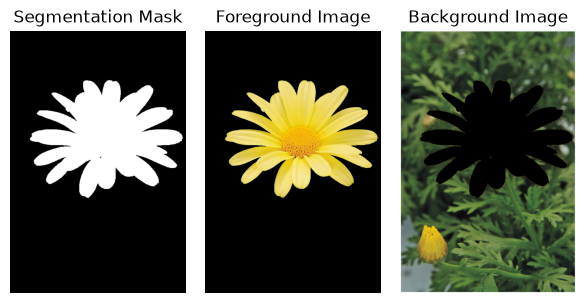

In [282]:
foreground = daisy * mask2[:, :, np.newaxis]
background = cv.subtract(daisy, foreground)
fig, axs = plt.subplots(1, 3, figsize=(6, 3))
axs[0].imshow(mask2, cmap='gray')
axs[0].set_title('Segmentation Mask')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
axs[1].set_title('Foreground Image')
axs[1].axis('off')
axs[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
axs[2].set_title('Background Image')
axs[2].axis('off')
plt.tight_layout()
plt.show()

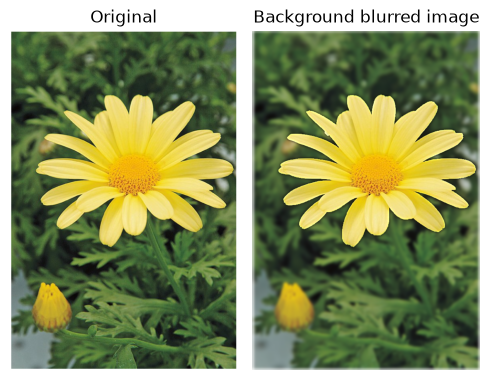

In [283]:
blurred_background = cv.GaussianBlur(background, (25, 25), 3)
blurred = cv.add(foreground, blurred_background)
fig, axs = plt.subplots(1, 2, figsize=(5, 4))
axs[0].imshow(cv.cvtColor(daisy, cv.COLOR_BGR2RGB))
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
axs[1].set_title('Background blurred image')
axs[1].axis('off')
plt.tight_layout()
plt.show()

c) The darker area just outside the flower is due to background pixels being set to black (0) in the isolated background layer prior to applying the blur effect.
The smoothing filter that is applied to the rest of the background pixel values near this boundary, averages the valid rest of the background pixels with the black pixels of the empty cutout space. This mathematical mixing takes the intensity of the neighboring background pixels down significantly, creating a dark “halo” or shadow effect right around the flower.
The valid background-area image colors are then blended together, and to avoid this artifact, the area in the foreground layer must be artificially filled with valid background colours, for example, by using image inpainting (to synthesize the background colours and textures from neighbouring areas).

Question 10

In [284]:
img = cv2.imread('mountain.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (150, 150))

In [285]:
d = 9
sig_space = 75.0
sig_color = 75.0
blur = cv2.GaussianBlur(img, (d, d), sig_space)
cv_bilateral = cv2.bilateralFilter(img, d, sig_color, sig_space)
my_final_img = np.zeros((img.shape[0], img.shape[1], 3), np.uint8)
half = d // 2
padded = cv2.copyMakeBorder(img, half, half, half, half, cv2.BORDER_REFLECT)

In [286]:
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        for c in range(3):
            total_weight = 0
            pixel_sum = 0
            for x in range(d):
                for y in range(d):
                    dist = math.sqrt((x - half)**2 + (y - half)**2)
                    space_w = math.exp(-(dist**2) / (2 * (sig_space**2)))
                    c_diff = abs(int(padded[i+x, j+y, c]) - int(padded[i+half, j+half, c]))
                    color_w = math.exp(-(c_diff**2) / (2 * (sig_color**2)))       
                    w = space_w * color_w
                    total_weight = total_weight + w
                    pixel_sum = pixel_sum + (w * padded[i+x, j+y, c])
            my_final_img[i, j, c] = int(pixel_sum / total_weight)
error = np.mean((cv_bilateral - my_final_img) ** 2)
psnr = 20 * math.log10(255.0 / math.sqrt(error))
print("mse is:", error)
print("psnr is:", psnr)

mse is: 48.13983703703704
psnr is: 31.3057574509997


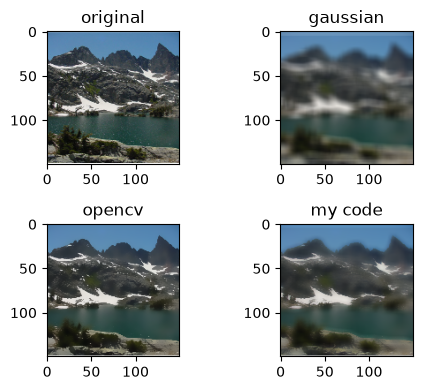

In [289]:
plt.figure(figsize=(5, 4))
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title('original')
plt.subplot(2, 2, 2)
plt.imshow(blur)
plt.title('gaussian')
plt.subplot(2, 2, 3)
plt.imshow(cv_bilateral)
plt.title('opencv')
plt.subplot(2, 2, 4)
plt.imshow(my_final_img)
plt.title('my code')
plt.tight_layout()
plt.show()